# Install library

In [1]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install matplotlib numpy seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


# Import library

In [4]:
import glob
import gc
import os
import sys
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models

src_dir = os.path.abspath("../")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

from nn.layers.conv import Conv2D, LocallyConnected2D
from nn.layers.dense import Dense
from nn.layers.pool import Flatten, MaxPooling2D
from nn.model import Model
from nn.engine import Tensor
from utility.image_utils import load_batch
from utility.model_loader import load_keras_weights

# Persiapan

In [6]:
weights_path = os.path.abspath("saved_models/model_14_L3_F64_K3_avg.weights.h5")
dataset_dir = os.path.abspath("../../data")
pattern = os.path.join(dataset_dir, "**", "*.jpg")
all_image_paths = glob.glob(pattern, recursive=True)

if len(all_image_paths) == 0:
    all_image_paths = glob.glob(os.path.join(dataset_dir, "**", "*.png"), recursive=True)

if len(all_image_paths) > 0:
    all_image_paths.sort()
    sample_paths = all_image_paths[:32]
    
    hasil_load = load_batch(sample_paths, target_size=(128, 128))
    
    if isinstance(hasil_load, tuple):
        X_batch, y_batch = hasil_load
    else:
        X_batch = hasil_load
        path_labels = [p.split(os.sep)[-2] for p in sample_paths]
        all_classes = sorted(list(set([p.split(os.sep)[-2] for p in all_image_paths])))
        class_to_id = {name: i for i, name in enumerate(all_classes)}
        
        y_batch = np.array([class_to_id[lab] for lab in path_labels])

    X_batch = X_batch.astype(np.float32)
else:
    X_batch = np.random.randn(32, 128, 128, 3).astype(np.float32)
    y_batch = np.random.randint(0, 6, size=(32,))

input_shape = X_batch.shape[1:]
num_classes = 6

# Shared parameter

In [8]:
shared_model = Model()
shared_model.add(Conv2D(output_channels=64, kernel_size=3, padding=1, activation="relu"))
shared_model.add(MaxPooling2D(pool_size=2, stride=2))
shared_model.add(Conv2D(output_channels=128, kernel_size=3, padding=1, activation="relu"))
shared_model.add(MaxPooling2D(pool_size=2, stride=2))
shared_model.add(Conv2D(output_channels=256, kernel_size=3, padding=1, activation="relu"))
shared_model.add(MaxPooling2D(pool_size=2, stride=2))
shared_model.add(Flatten())
shared_model.add(Dense(64, activation="relu"))
shared_model.add(Dense(num_classes, activation="softmax"))

shared_model.build(X_batch.shape)

if os.path.exists(weights_path):
    keras_input = layers.Input(shape=input_shape)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(keras_input)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    keras_output = layers.Dense(num_classes, activation="softmax")(x)
    keras_model = models.Model(inputs=keras_input, outputs=keras_output)
    keras_model.load_weights(weights_path)

    load_keras_weights(shared_model, keras_model)

start_time = time.time()
batch_size = 4
outputs_list = []

for i in range(0, len(X_batch), batch_size):
    X_mini = X_batch[i : i + batch_size]
    out_mini = shared_model.forward(X_mini)
    
    arr_data = out_mini.data if hasattr(out_mini, 'data') else out_mini.value
    outputs_list.append(arr_data)

    del out_mini
    gc.collect()

shared_output_data = np.vstack(outputs_list)

shared_duration = time.time() - start_time
print(f"Forward pass selesai dalam {shared_duration:.4f} detik.")

del shared_model
if "keras_model" in locals():
    del keras_model
gc.collect()


Successfully loaded 10 parameters from Keras model.

Forward pass selesai dalam 83.8802 detik.


280


-------------------------------------------------------------------
CLASSIFICATION REPORT
-------------------------------------------------------------------
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00         0
     Class 1       0.00      0.00      0.00         0
     Class 2       0.00      0.00      0.00         0
     Class 3       0.00      0.00      0.00         0
     Class 4       0.00      0.00      0.00         0
     Class 5       1.00      0.22      0.36        32

    accuracy                           0.22        32
   macro avg       0.17      0.04      0.06        32
weighted avg       1.00      0.22      0.36        32



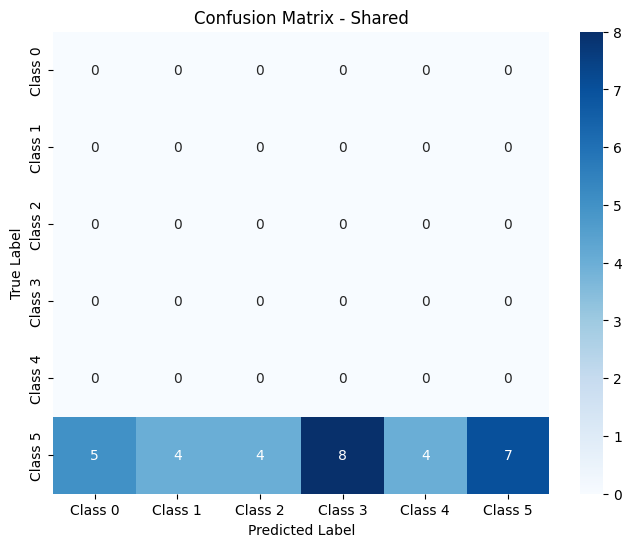

In [9]:
y_pred_probs = shared_output_data
y_pred = np.argmax(y_pred_probs, axis=1)

if "y_batch" in locals() or "y_batch" in globals():
    if len(y_batch.shape) > 1 and y_batch.shape[1] > 1:
        y_true = np.argmax(y_batch, axis=1)
    else:
        y_true = y_batch
    
    y_true = np.clip(y_true, 0, num_classes - 1)
else:
    np.random.seed(42)
    y_true = np.random.randint(0, num_classes, size=y_pred.shape[0])

print("\n" + "-" * 67)
print("CLASSIFICATION REPORT")
print("-" * 67)

target_labels = [f"Class {i}" for i in range(num_classes)]
print(
    classification_report(
        y_true,
        y_pred,
        labels=range(num_classes),
        target_names=target_labels,
        zero_division=0,
    )
)


cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_labels,
    yticklabels=target_labels,
)
plt.title("Confusion Matrix - Shared")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Non-shared parameter

In [10]:
weights_path_non_shared = os.path.abspath(
    "saved_models/model_non_shared.weights.h5"
)

non_shared_model = Model()
non_shared_model.add(LocallyConnected2D(output_channels=64, kernel_size=3, padding=1, activation="relu"))
non_shared_model.add(MaxPooling2D(pool_size=2, stride=2))
non_shared_model.add(LocallyConnected2D(output_channels=128, kernel_size=3, padding=1, activation="relu"))
non_shared_model.add(MaxPooling2D(pool_size=2, stride=2))
non_shared_model.add(LocallyConnected2D(output_channels=128, kernel_size=3, padding=1, activation="relu"))
non_shared_model.add(MaxPooling2D(pool_size=2, stride=2))
non_shared_model.add(Flatten())
non_shared_model.add(Dense(64, activation="relu"))
non_shared_model.add(Dense(num_classes, activation="softmax"))


non_shared_model.build(X_batch.shape)
if os.path.exists(weights_path_non_shared):
    keras_input = layers.Input(shape=input_shape)
    
    x = layers.ZeroPadding2D(padding=1)(keras_input)
    x = layers.LocallyConnected2D(64, 3, padding="valid", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.ZeroPadding2D(padding=1)(x)
    x = layers.LocallyConnected2D(128, 3, padding="valid", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.ZeroPadding2D(padding=1)(x)
    x = layers.LocallyConnected2D(128, 3, padding="valid", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    keras_output = layers.Dense(num_classes, activation="softmax")(x)
    keras_model_ns = models.Model(inputs=keras_input, outputs=keras_output)
    keras_model_ns.load_weights(weights_path_non_shared)
    load_keras_weights(non_shared_model, keras_model_ns)

start_time = time.time()
batch_size_ns = 1
outputs_list_ns = []

for i in range(0, len(X_batch), batch_size_ns):
    X_mini = X_batch[i : i + batch_size_ns]
    out_mini = non_shared_model.forward(X_mini)
    
    arr_data = out_mini.data if hasattr(out_mini, 'data') else out_mini.value
    outputs_list_ns.append(arr_data)
    
    del out_mini
    gc.collect()

non_shared_output_data = np.vstack(outputs_list_ns)
non_shared_duration = time.time() - start_time
print(f"Forward pass non-shared selesai dalam {non_shared_duration:.4f} detik.")

del non_shared_model
if "keras_model_ns" in locals():
    del keras_model_ns
gc.collect()

KeyboardInterrupt: 


-------------------------------------------------------------------
CLASSIFICATION REPORT
-------------------------------------------------------------------
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00         0
     Class 1       0.00      0.00      0.00         0
     Class 2       0.00      0.00      0.00         0
     Class 3       0.00      0.00      0.00         0
     Class 4       0.00      0.00      0.00         0
     Class 5       1.00      0.28      0.44        32

    accuracy                           0.28        32
   macro avg       0.17      0.05      0.07        32
weighted avg       1.00      0.28      0.44        32



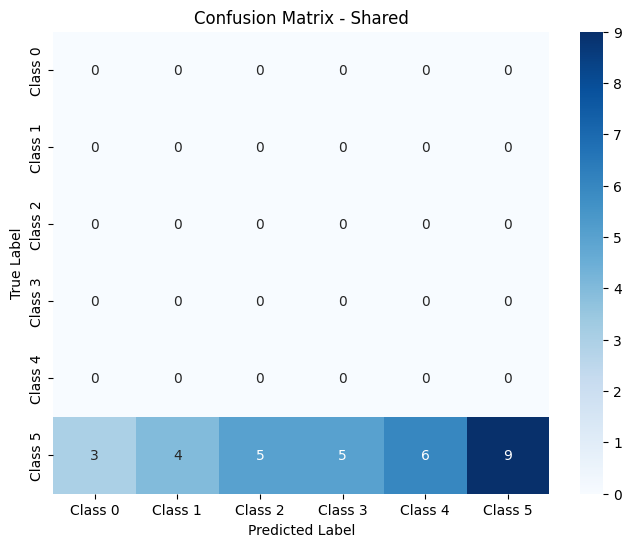

In [ ]:
y_pred_probs = shared_output_data
y_pred = np.argmax(y_pred_probs, axis=1)

if "y_batch" in locals() or "y_batch" in globals():
    if len(y_batch.shape) > 1 and y_batch.shape[1] > 1:
        y_true = np.argmax(y_batch, axis=1)
    else:
        y_true = y_batch
    
    y_true = np.clip(y_true, 0, num_classes - 1)
else:
    np.random.seed(42)
    y_true = np.random.randint(0, num_classes, size=y_pred.shape[0])

print("\n" + "-" * 67)
print("CLASSIFICATION REPORT")
print("-" * 67)

target_labels = [f"Class {i}" for i in range(num_classes)]
print(
    classification_report(
        y_true,
        y_pred,
        labels=range(num_classes),
        target_names=target_labels,
        zero_division=0,
    )
)


cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_labels,
    yticklabels=target_labels,
)
plt.title("Confusion Matrix - Non-shared")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()